In [15]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [16]:
# LOAD DATASET

from google.colab import files
uploaded = files.upload()

Saving Lending Club dataset.xlsx to Lending Club dataset (1).xlsx


In [17]:
# Read the uploaded Excel file

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

In [19]:
# INITIAL DATA INSPECTION

print("First 5 rows:")
display(df.head())

First 5 rows:


,id,member_id,term,purpose,loan_status,loan_amnt,int_rate,installment,home_ownership,annual_inc,verification_status,revol_bal,revol_util,total_acc,acc_open_past_24mths,total_pymnt
0,62286683,66483442,36 months,credit_card,Fully Paid,24000,7.89,750.86,MORTGAGE,237500.0,Source Verified,28279,36.9,25,5,24948.450004
1,46314315,49422035,36 months,credit_card,Fully Paid,8000,6.68,245.85,RENT,41000.0,Not Verified,24377,51.0,29,2,8351.630000
2,51317198,54726945,36 months,credit_card,Fully Paid,12175,9.17,388.13,MORTGAGE,100000.0,Not Verified,21329,64.6,17,3,13205.910000
3,42984750,45981489,36 months,credit_card,Charged Off,6400,6.92,197.38,RENT,41900.0,Source Verified,14936,73.2,15,1,3550.380000
4,42181434,45138158,36 months,credit_card,Fully Paid,12600,6.68,387.22,OWN,73800.0,Not Verified,9904,20.7,25,4,13125.770000


In [20]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,id,member_id,term,purpose,loan_status,loan_amnt,int_rate,installment,home_ownership,annual_inc,verification_status,revol_bal,revol_util,total_acc,acc_open_past_24mths,total_pymnt
7146,38332310,41116076,36 months,credit_card,Fully Paid,5000,17.14,178.62,MORTGAGE,32500.0,Verified,9600,55.8,37,9,5616.01000
7147,45374391,48482120,36 months,credit_card,Fully Paid,5000,8.18,157.10,OWN,60000.0,Not Verified,17667,67.9,21,2,5334.51000
7148,60771081,64812826,36 months,credit_card,Fully Paid,13800,8.18,433.59,MORTGAGE,94000.0,Source Verified,16419,55.8,31,9,14187.90993
7149,40420518,43285242,36 months,credit_card,Fully Paid,19175,17.14,684.98,MORTGAGE,80000.0,Not Verified,46559,71.1,24,6,22197.23000
7150,48736410,51985202,36 months,credit_card,Fully Paid,4400,13.33,148.96,RENT,42000.0,Verified,3810,30.0,16,9,4931.39000


In [21]:
print("\nDataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset dimensions:
Rows: 7151
Columns: 16


In [22]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['id', 'member_id', 'term', 'purpose', 'loan_status', 'loan_amnt', 'int_rate', 'installment', 'home_ownership', 'annual_inc', 'verification_status', 'revol_bal', 'revol_util', 'total_acc', 'acc_open_past_24mths', 'total_pymnt']


In [24]:
# DATA TYPES AND INFORMATION

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7151 entries, 0 to 7150
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7151 non-null   int64  
 1   member_id             7151 non-null   int64  
 2   term                  7151 non-null   object 
 3   purpose               7151 non-null   object 
 4   loan_status           7151 non-null   object 
 5   loan_amnt             7151 non-null   int64  
 6   int_rate              7151 non-null   float64
 7   installment           7151 non-null   float64
 8   home_ownership        7151 non-null   object 
 9   annual_inc            7151 non-null   float64
 10  verification_status   7151 non-null   object 
 11  revol_bal             7151 non-null   int64  
 12  revol_util            7148 non-null   float64
 13  total_acc             7151 non-null   int64  
 14  acc_open_past_24mths  7151 non-null   int64  
 15  

In [25]:
# DESCRIPTIVE STATISTICS

print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,id,member_id,loan_amnt,int_rate,installment,annual_inc,revol_bal,revol_util,total_acc,acc_open_past_24mths,total_pymnt
count,7.151000e+03,7.151000e+03,7151.000000,7151.000000,7151.000000,7.151000e+03,7151.000000,7148.000000,7151.000000,7151.000000,7151.000000
mean,5.106186e+07,5.453440e+07,13579.373514,10.431779,440.715538,7.624496e+04,18807.828695,53.768145,25.880856,4.894840,12830.463838
std,9.419570e+06,1.003211e+07,8148.555935,3.316630,266.743864,5.456859e+04,26051.747852,22.725538,12.494253,3.237648,8946.447110
min,5.800840e+05,7.457430e+05,1000.000000,5.320000,30.850000,8.000000e+03,0.000000,0.000000,4.000000,0.000000,0.000000
25%,4.229390e+07,4.525578e+07,7500.000000,7.890000,243.130000,4.500000e+04,7328.500000,36.900000,17.000000,3.000000,6162.895000
50%,5.044621e+07,5.381612e+07,11425.000000,9.990000,367.190000,6.500000e+04,12781.000000,53.500000,24.000000,4.000000,10605.060000
75%,5.923142e+07,6.311782e+07,18600.000000,12.690000,609.360000,9.300000e+04,22059.000000,70.900000,33.000000,7.000000,17410.045000
max,6.861588e+07,7.351869e+07,35000.000000,25.800000,1309.490000,1.900000e+06,838698.000000,113.100000,100.000000,25.000000,44465.780009


In [28]:
# MISSING VALUE ANALYSIS

missing_values = df.isnull().sum()

In [29]:
missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing': (missing_values / len(df)) * 100
})

In [30]:
display(missing_table)

,Missing Values,Percentage Missing
id,0,0.000000
member_id,0,0.000000
term,0,0.000000
purpose,0,0.000000
loan_status,0,0.000000
loan_amnt,0,0.000000
int_rate,0,0.000000
installment,0,0.000000
home_ownership,0,0.000000
annual_inc,0,0.000000


In [31]:
# DUPLICATE CHECK

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [32]:
# TARGET VARIABLE ANALYSIS

print("Loan Status Counts:")
display(df['loan_status'].value_counts())

Loan Status Counts:


,count
loan_status,
Fully Paid,5943
Charged Off,1208


In [33]:
print("\nLoan Status Percentages:")
display(df['loan_status'].value_counts(normalize=True) * 100)


Loan Status Percentages:


,proportion
loan_status,
Fully Paid,83.107258
Charged Off,16.892742


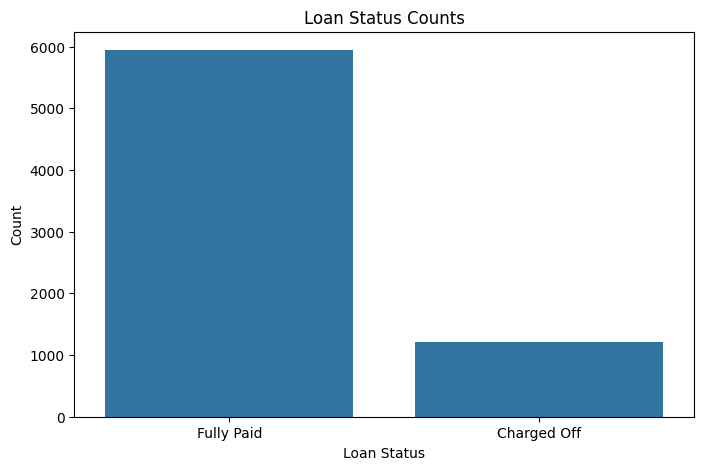

In [38]:
# TARGET VARIABLE VISUALIZATION

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='loan_status')
plt.title('Loan Status Counts')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

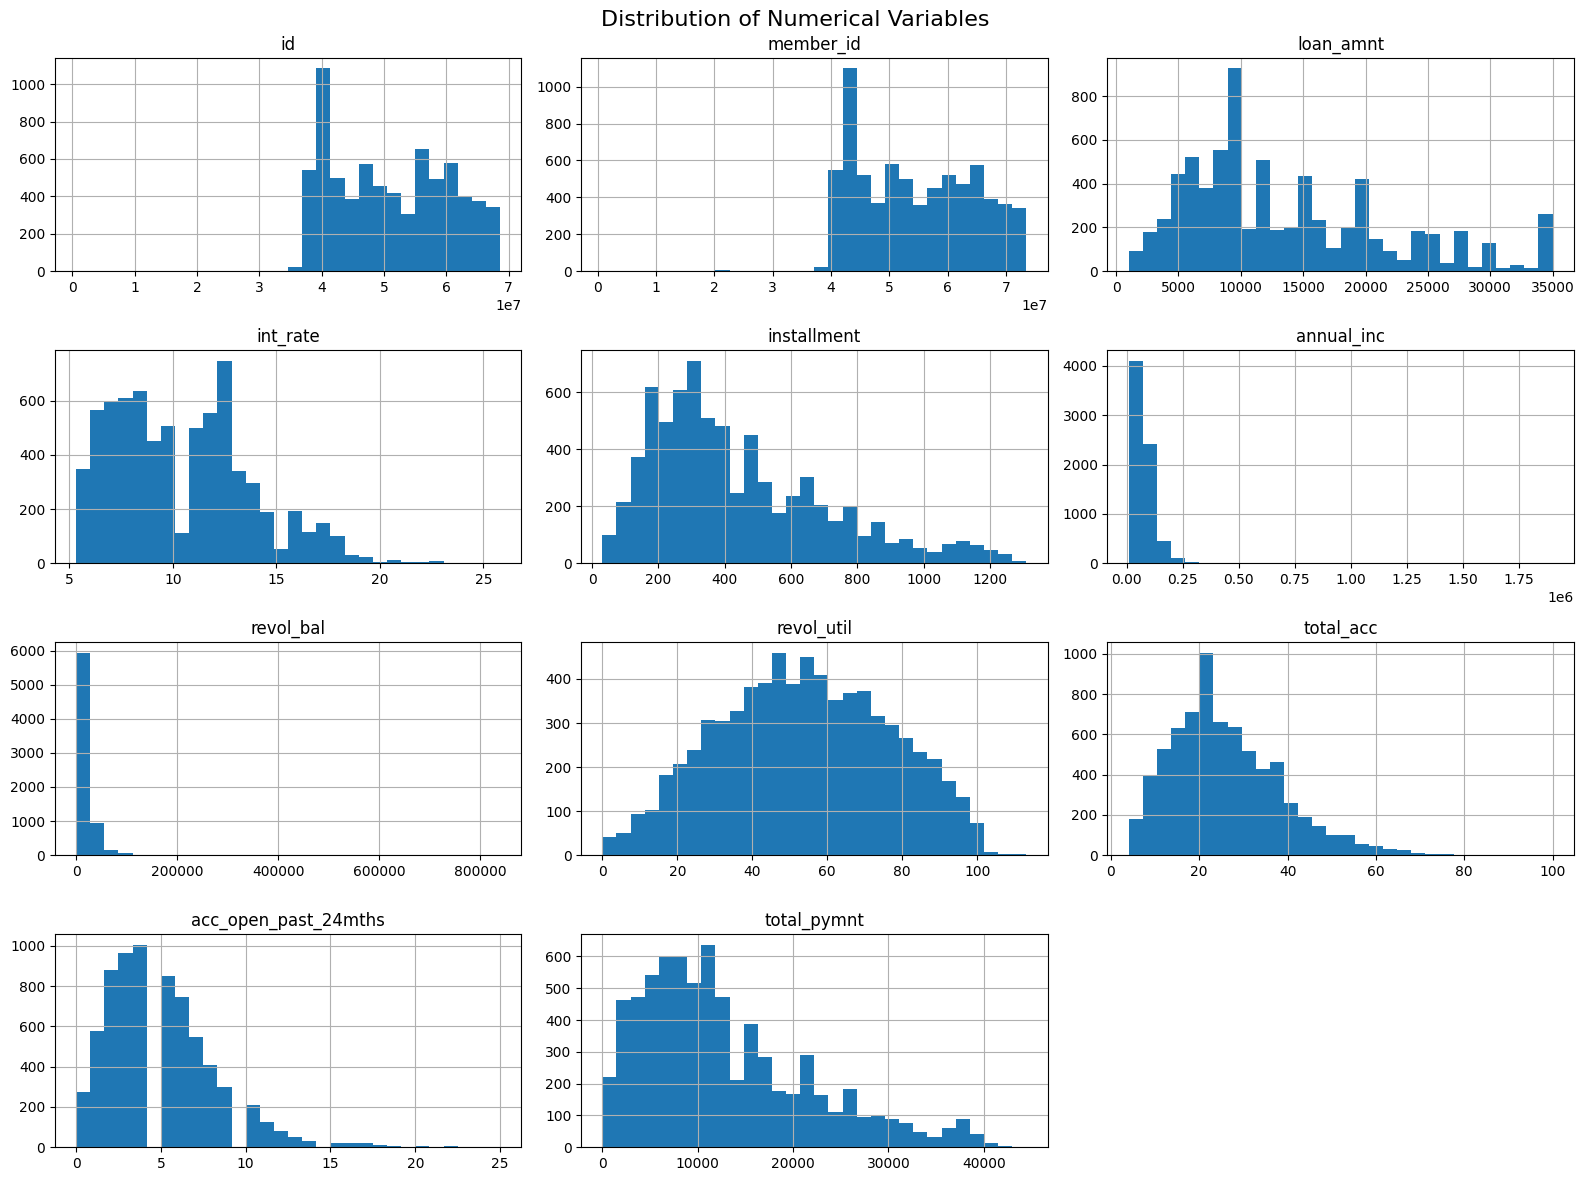

In [41]:
# NUMERICAL VARIABLE DISTRIBUTIONS

numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)
plt.suptitle(
    'Distribution of Numerical Variables',
    fontsize=16
)

plt.tight_layout()
plt.show()

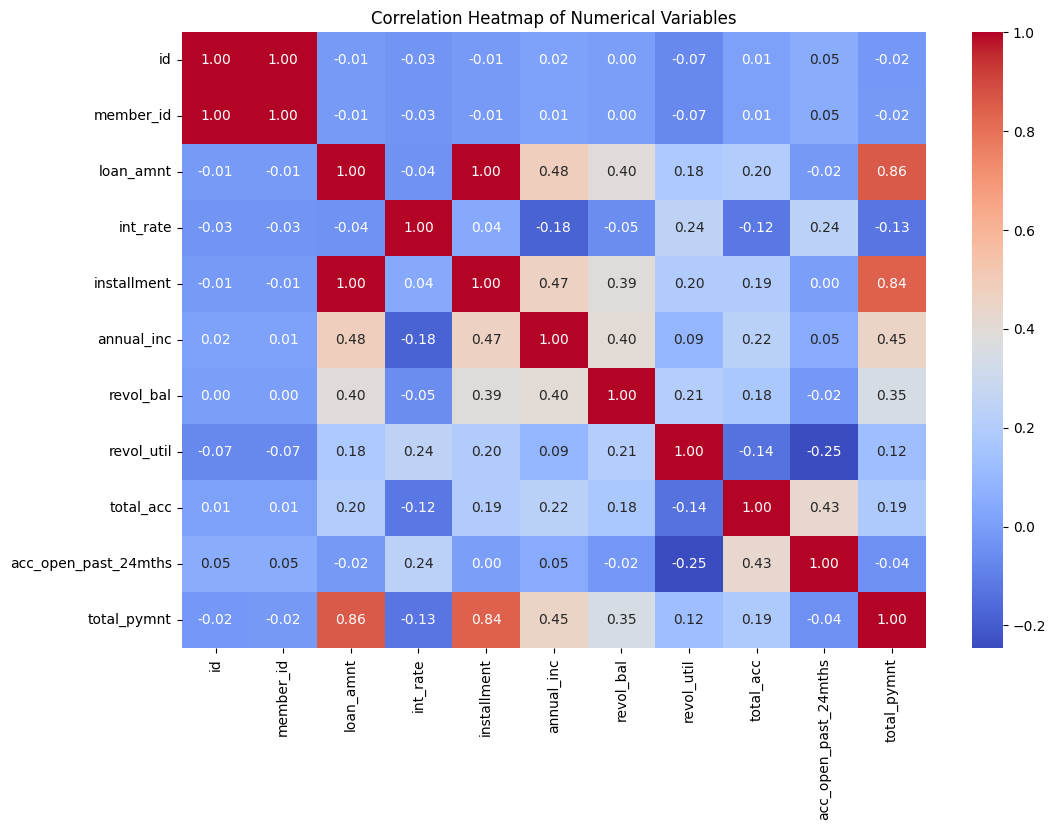

In [42]:
# CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(
    include=np.number
).corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [47]:
# CATEGORICAL VARIABLE ANALYSIS

categorical_columns = df.select_dtypes(
    include='object'
).columns
for column in categorical_columns:
    print("\n" + "="*20)
    print(column)
    print("="*20)
    display(df[column].value_counts())


term


,count
term,
36 months,7151



purpose


,count
purpose,
credit_card,7151



loan_status


,count
loan_status,
Fully Paid,5943
Charged Off,1208



home_ownership


,count
home_ownership,
MORTGAGE,3243
RENT,3075
OWN,833



verification_status


,count
verification_status,
Source Verified,2939
Not Verified,2354
Verified,1858


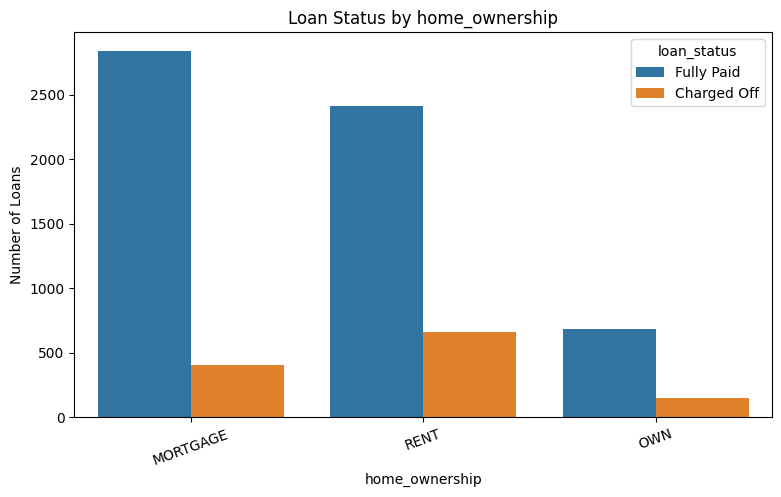

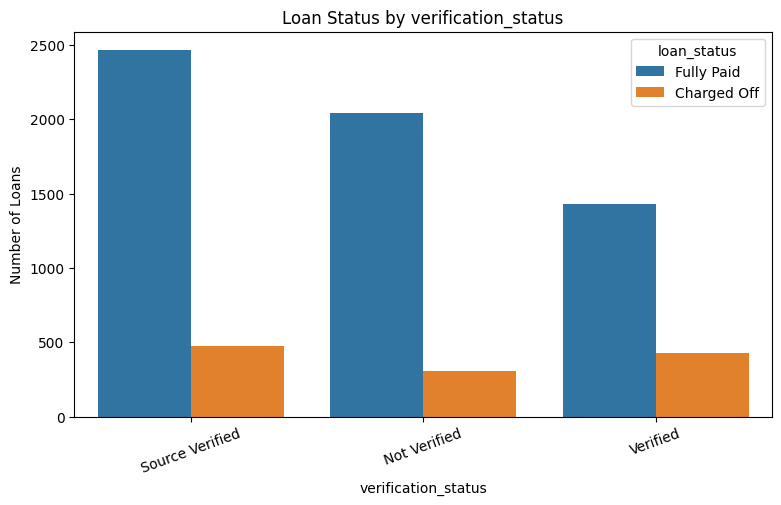

In [48]:
# LOAN STATUS VS CATEGORICAL VARIABLES
categorical_features = [
    'home_ownership',
    'verification_status'
]
for column in categorical_features:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=df,
        x=column,
        hue='loan_status'
    )
    plt.title(f'Loan Status by {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Loans')
    plt.xticks(rotation=20)
    plt.show()

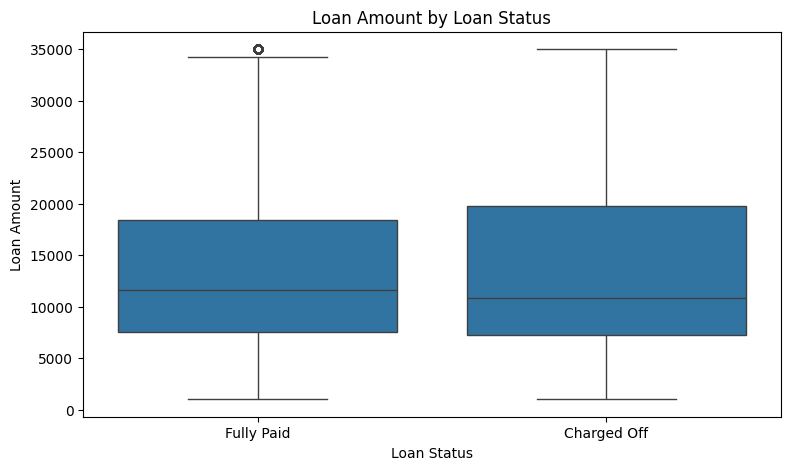

In [49]:
# LOAN AMOUNT VS LOAN STATUS

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='loan_status',
    y='loan_amnt'
)
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

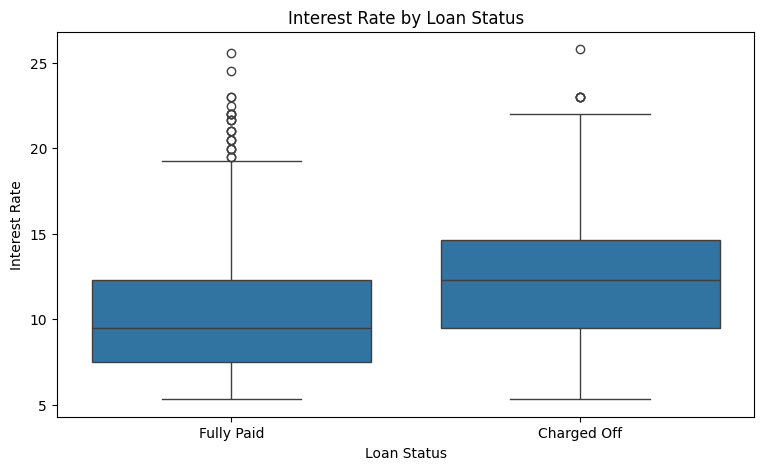

In [51]:
# INTEREST RATE VS LOAN STATUS

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='loan_status',
    y='int_rate'
)
plt.title('Interest Rate by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate')
plt.show()

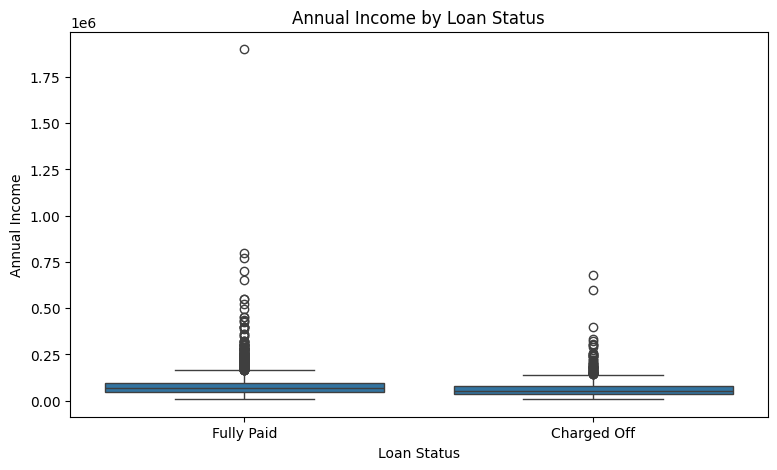

In [52]:
# ANNUAL INCOME VS LOAN STATUS

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='loan_status',
    y='annual_inc'
)
plt.title('Annual Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income')
plt.show()

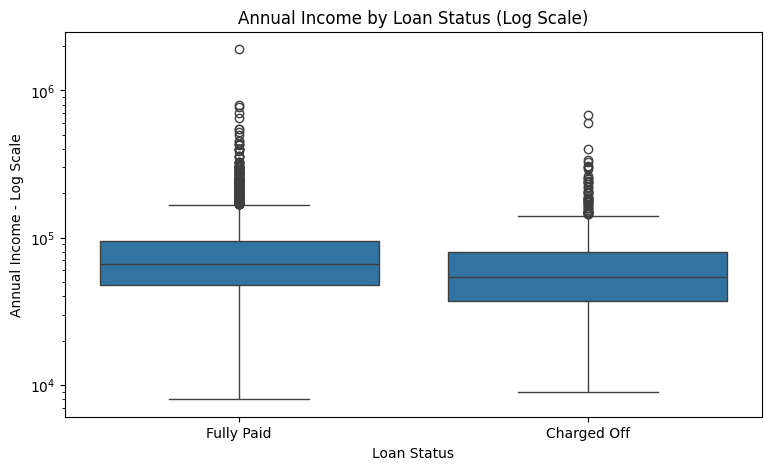

In [53]:
# Log-scale visualization of annual income

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='loan_status',
    y='annual_inc'
)
plt.yscale('log')
plt.title('Annual Income by Loan Status (Log Scale)')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income - Log Scale')
plt.show()

In [55]:
# DEFINE FEATURES AND TARGET

features = [
    'loan_amnt',
    'int_rate',
    'installment',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'revol_bal',
    'revol_util',
    'total_acc',
    'acc_open_past_24mths'
]
X = df[features].copy()
y = df['loan_status'].copy()

In [56]:
print("Feature matrix shape:", X.shape)

Feature matrix shape: (7151, 10)


In [57]:
print("Target shape:", y.shape)

Target shape: (7151,)


In [59]:
print("\nFeatures used:")
print(features)


Features used:
['loan_amnt', 'int_rate', 'installment', 'home_ownership', 'annual_inc', 'verification_status', 'revol_bal', 'revol_util', 'total_acc', 'acc_open_past_24mths']


In [60]:
print("\nTarget classes:")
print(y.unique())


Target classes:
['Fully Paid' 'Charged Off']


In [61]:
# IDENTIFY FEATURE TYPES

numeric_features = [
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'revol_bal',
    'revol_util',
    'total_acc',
    'acc_open_past_24mths'
]

In [62]:
categorical_features = [
    'home_ownership',
    'verification_status'
]

In [63]:
print("Numerical features:")
print(numeric_features)

Numerical features:
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'revol_bal', 'revol_util', 'total_acc', 'acc_open_past_24mths']


In [64]:
print("\nCategorical features:")
print(categorical_features)


Categorical features:
['home_ownership', 'verification_status']


In [65]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5720, 10)
Testing set size: (1431, 10)


In [67]:
print("\nTraining target distribution:")
print(y_train.value_counts())


Training target distribution:
loan_status
Fully Paid     4754
Charged Off     966
Name: count, dtype: int64


In [68]:
print("\nTesting target distribution:")
print(y_test.value_counts())


Testing target distribution:
loan_status
Fully Paid     1189
Charged Off     242
Name: count, dtype: int64


In [69]:
# PREPROCESSING

from sklearn.impute import SimpleImputer

# Numerical preprocessing:
# Missing values are replaced with the median
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

In [70]:
# Categorical preprocessing:
# Missing values are replaced with the most frequent category
# and categorical variables are converted to dummy variables
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [71]:
# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [72]:
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [73]:
# CART MODEL

cart_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            criterion='gini',
            random_state=42,
            max_depth=5
        ))
    ]
)
print("CART model created successfully.")

CART model created successfully.


In [74]:
# TRAIN CART MODEL

cart_model.fit(X_train, y_train)
print("CART model trained successfully.")

CART model trained successfully.


In [75]:
# MAKE PREDICTIONS

y_pred = cart_model.predict(X_test)
print("Predictions generated successfully.")
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid'
 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid'
 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid'
 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid' 'Fully Paid']


In [76]:
# MODEL ACCURACY

accuracy = accuracy_score(y_test, y_pred)
print("CART Model Accuracy:")
print(f"{accuracy:.4f}")
print(f"\nAccuracy: {accuracy * 100:.2f}%")

CART Model Accuracy:
0.8274

Accuracy: 82.74%


In [77]:
# CLASSIFICATION METRICS

precision = precision_score(
    y_test,
    y_pred,
    pos_label='Charged Off'
)
recall = recall_score(
    y_test,
    y_pred,
    pos_label='Charged Off'
)
f1 = f1_score(
    y_test,
    y_pred,
    pos_label='Charged Off'
)

In [78]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8274
Precision: 0.4194
Recall   : 0.0537
F1 Score : 0.0952


In [79]:
# CLASSIFICATION REPORT

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.42      0.05      0.10       242
  Fully Paid       0.84      0.98      0.90      1189

    accuracy                           0.83      1431
   macro avg       0.63      0.52      0.50      1431
weighted avg       0.77      0.83      0.77      1431



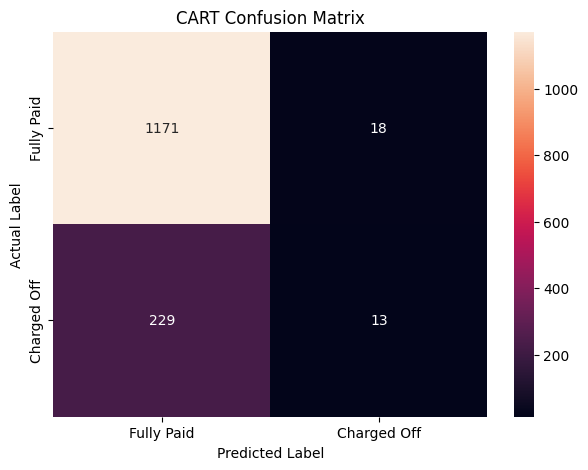

In [80]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Fully Paid', 'Charged Off']
)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Fully Paid', 'Charged Off'],
    yticklabels=['Fully Paid', 'Charged Off']
)
plt.title('CART Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

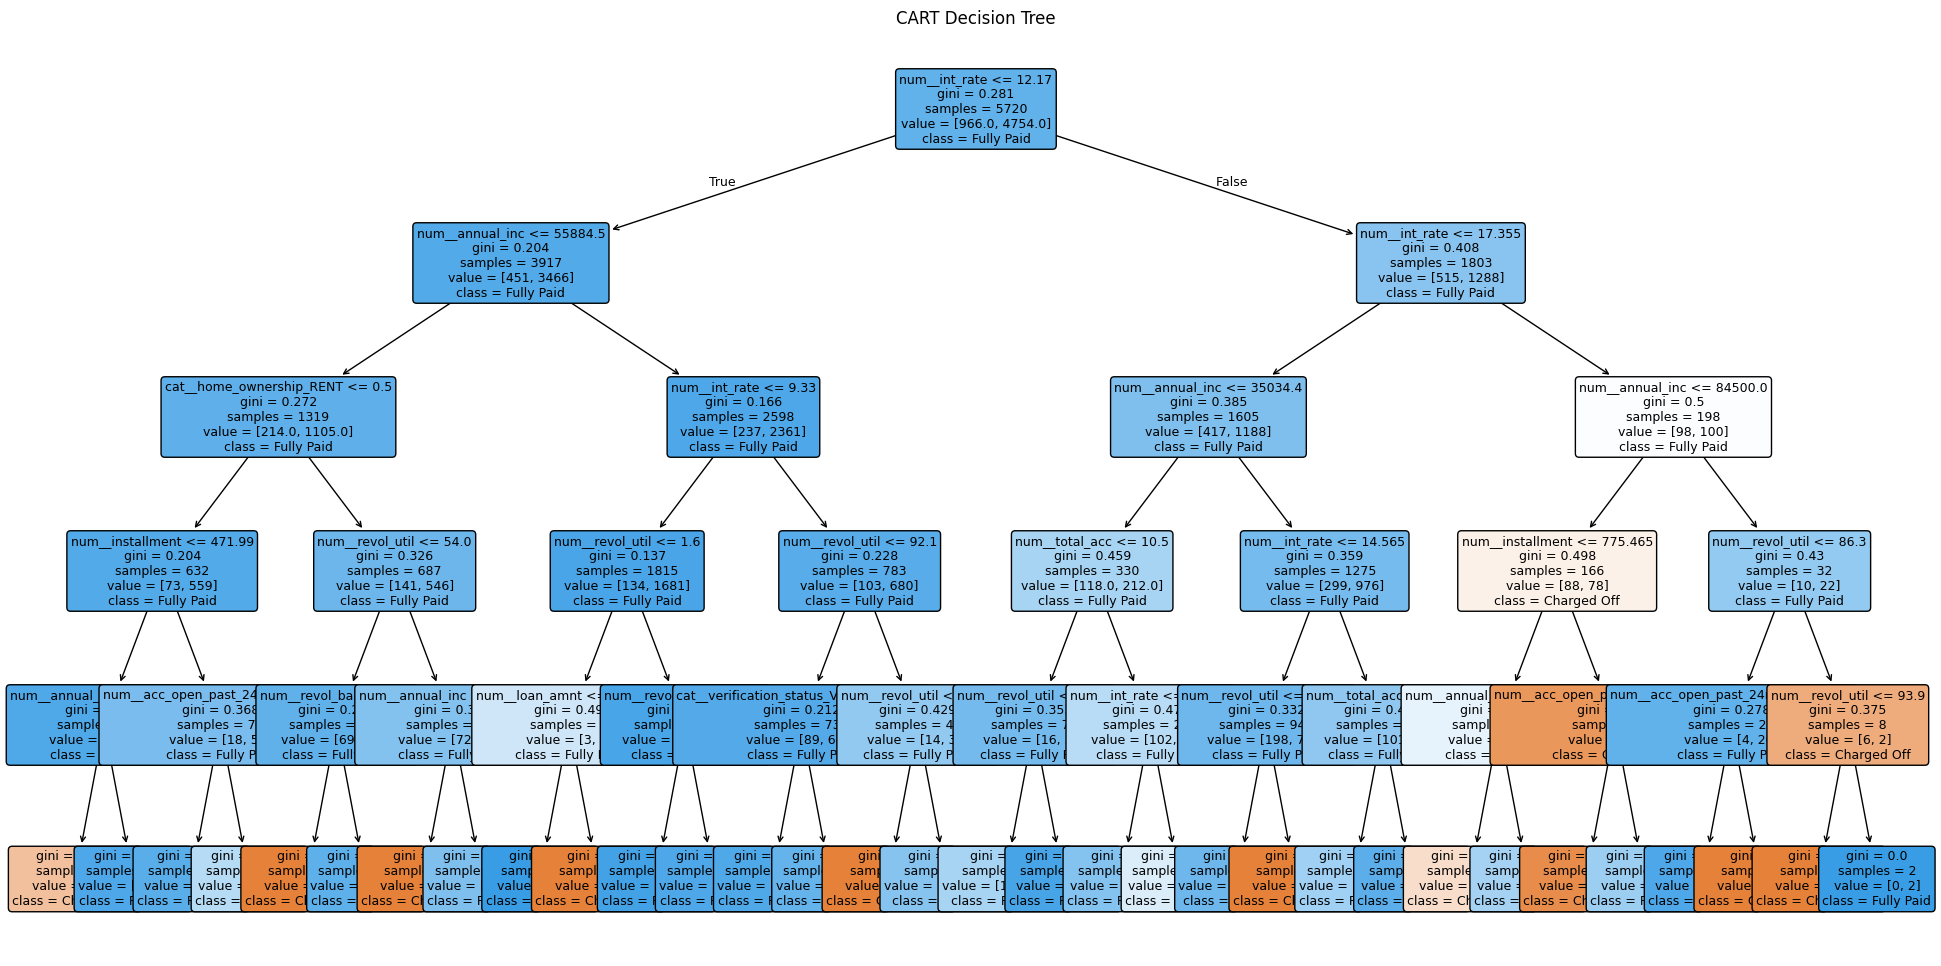

In [81]:
# VISUALIZE CART DECISION TREE

# Get the trained decision tree
tree_model = cart_model.named_steps['classifier']

# Get feature names after one-hot encoding
feature_names = cart_model.named_steps[
    'preprocessor'
].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('CART Decision Tree')
plt.show()

In [82]:
# FEATURE IMPORTANCE

importance = tree_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)
display(feature_importance_df)

,Feature,Importance
1,num__int_rate,0.526785
3,num__annual_inc,0.154737
5,num__revol_util,0.129014
2,num__installment,0.048301
6,num__total_acc,0.036328
7,num__acc_open_past_24mths,0.036202
10,cat__home_ownership_RENT,0.027209
0,num__loan_amnt,0.017598
4,num__revol_bal,0.014447
13,cat__verification_status_Verified,0.009379


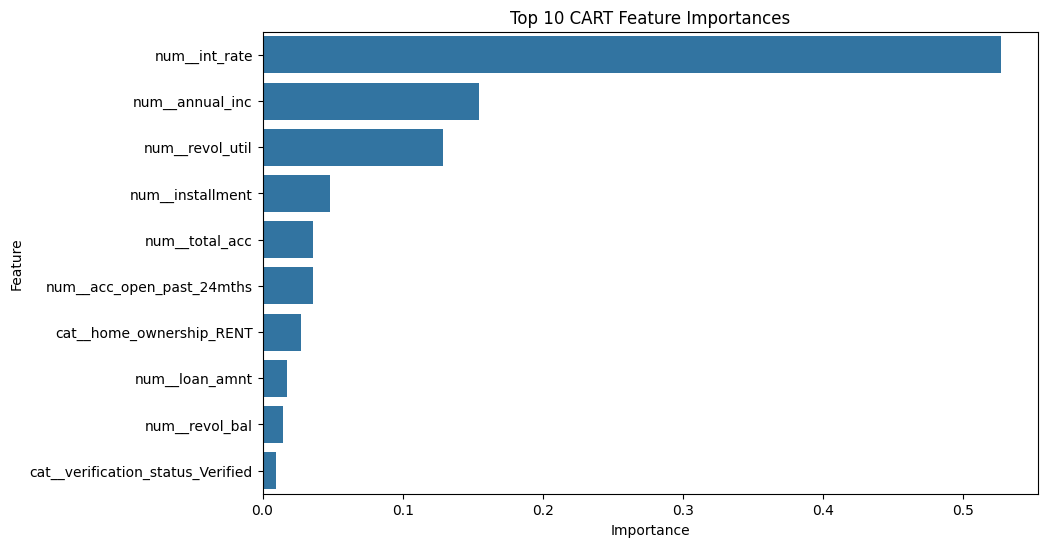

In [83]:
# FEATURE IMPORTANCE VISUALIZATION

top_features = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)
plt.title('Top 10 CART Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [91]:
# CART RESULTS TABLE

cart_results = pd.DataFrame({
    'Model': ['CART'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})
display(cart_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,CART,0.827393,0.419355,0.053719,0.095238


In [92]:
results = pd.DataFrame({
    'Model': ['CART', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [np.nan, np.nan, np.nan],
    'Precision': [np.nan, np.nan, np.nan],
    'Recall': [np.nan, np.nan, np.nan],
    'F1 Score': [np.nan, np.nan, np.nan]
})
display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,CART,NaN,NaN,NaN,NaN
1,Logistic Regression,NaN,NaN,NaN,NaN
2,Random Forest,NaN,NaN,NaN,NaN


In [93]:
# CHECK FOR OVERFITTING

train_accuracy = cart_model.score(X_train, y_train)
test_accuracy = cart_model.score(X_test, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(
    f"\nDifference between training and testing accuracy: "
    f"{train_accuracy - test_accuracy:.4f}"
)

Training Accuracy: 0.8406
Testing Accuracy : 0.8274

Difference between training and testing accuracy: 0.0132


In [94]:
# TEST DIFFERENT TREE DEPTHS

depths = [2, 3, 4, 5, 6, 7, 8, 10, None]
depth_results = []
for depth in depths:

    model = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', DecisionTreeClassifier(
                criterion='gini',
                max_depth=depth,
                random_state=42
            ))
        ]
    )

    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    depth_results.append({
        'Max Depth': depth,
        'Training Accuracy': train_acc,
        'Testing Accuracy': test_acc
    })
depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df)

,Max Depth,Training Accuracy,Testing Accuracy
0,2.0,0.831119,0.830887
1,3.0,0.832867,0.826695
2,4.0,0.835140,0.828791
3,5.0,0.840559,0.827393
4,6.0,0.844056,0.816212
5,7.0,0.854021,0.802236
6,8.0,0.865035,0.806429
7,10.0,0.889161,0.796646
8,NaN,1.000000,0.737945


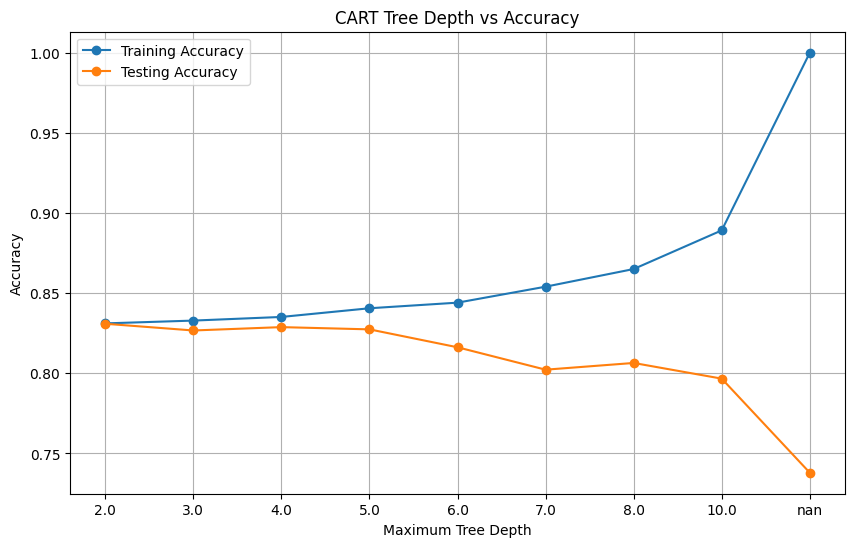

In [95]:
# TREE DEPTH VS ACCURACY

plt.figure(figsize=(10, 6))
plt.plot(
    depth_results_df['Max Depth'].astype(str),
    depth_results_df['Training Accuracy'],
    marker='o',
    label='Training Accuracy'
)
plt.plot(
    depth_results_df['Max Depth'].astype(str),
    depth_results_df['Testing Accuracy'],
    marker='o',
    label='Testing Accuracy'
)
plt.title('CART Tree Depth vs Accuracy')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()